In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scienceplots

from nanonets import Simulation
from nanonets.utils import load_simulation_results

plt.style.use(["science","bright","grid"])

# PARAMETERS
V_INPUT_MAX = 0.1
N_INPUTS    = 320
N_PARTICLES = [3,4,5,6,7,8,9,10,11,12,13,14,15]
N_E         = 2
V_INPUT     = np.round(np.linspace(-V_INPUT_MAX, V_INPUT_MAX, N_INPUTS),4)
V_I_PLOT    = 1000*V_INPUT
# PATH        = "/home/jonasmensing/bagheera/data/1_funding_period/iv_curves/networks/"
PATH        = "/mnt/c/Users/jonas/Desktop/phd/data/1_funding_period/iv_curves/stats/"
AC_TIME     = 40e-9
BATCH_TIME  = 20*AC_TIME
ELE_CHARGE  = 0.160217662
I_MIN       = ELE_CHARGE / (20*BATCH_TIME)
M_VALS      = [1,5,10,50,100,500,1000,5000,10000]

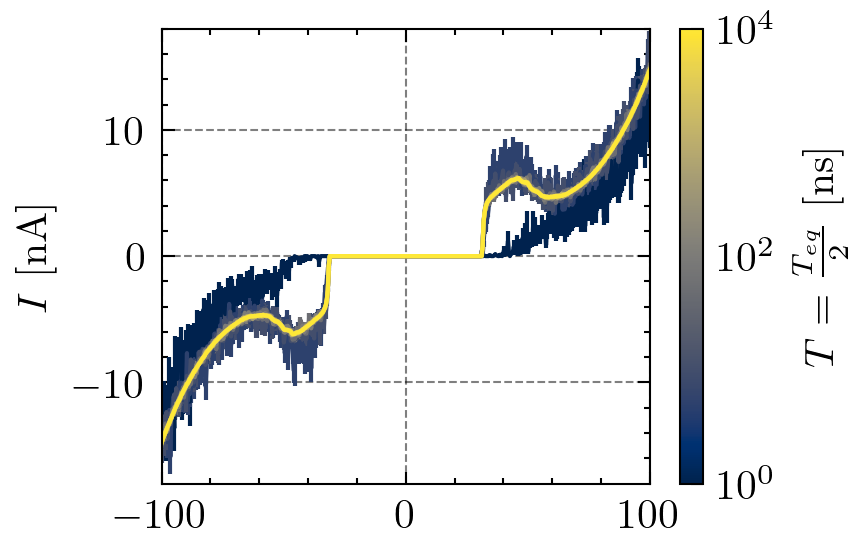

In [20]:
marker  = ['o','s','X','<','>','^','v']
norm    = mcolors.LogNorm(vmin=min(M_VALS),vmax=max(M_VALS))
cmap    = plt.get_cmap('cividis')
L       = 9
fig, ax = plt.subplots(dpi=300)
w, h    = fig.get_size_inches()
scale   = 0.75
fig.set_size_inches(w * scale, h * scale)

# Cg = 0
for M in M_VALS:
    df  = pd.read_csv(f"{PATH}Nx={L}_Ny={L}_Ne=8_{M}.csv").sort_values(by='E0').reset_index(drop=True)
    _   = ax.errorbar(df['E0'].values*1000, df['Observable'].values*1e-6, df['Error']*1e-6, color=cmap(norm(M)))

_ = ax.set_ylabel("$I~[\\mathrm{nA}]$")
_ = ax.set_ylim(-18,18)
_ = ax.set_xlim(-100,100)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("$T = \\frac{T_{eq}}{2}~[\mathrm{ns}]$")